In [10]:
import cv2
import numpy as np
import os
from glob import glob
from scipy.signal import find_peaks, savgol_filter, peak_widths

In [11]:
def preprocess_image(image_path, target_width=1024, crop_percent=0.05):

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    scale = target_width / w
    new_h = int(h * scale)

    resized = cv2.resize(gray, (target_width, new_h))

    h2, w2 = resized.shape
    crop_x = int(w2 * crop_percent)
    crop_y = int(h2 * crop_percent)

    cropped = resized[crop_y:h2-crop_y, crop_x:w2-crop_x]

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    equalized = clahe.apply(cropped)

    blurred = cv2.GaussianBlur(equalized, (5,5), 0)

    return img, blurred, scale, crop_x

In [12]:
def compute_projections(image):

    # Method 1: Sum projection
    proj1 = np.sum(image, axis=0)

    # Method 2: Median projection
    proj2 = np.median(image, axis=0)

    # Method 3: Gradient projection (Sobel X)
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobelx = np.abs(sobelx)
    proj3 = np.sum(sobelx, axis=0)

    # Normalize all
    projections = []
    for p in [proj1, proj2, proj3]:
        p = p / np.max(p)
        p = savgol_filter(p, 51, 3)
        projections.append(p)

    return projections

In [13]:
def detect_peaks_ensemble(projections):

    all_peaks = []

    for proj in projections:

        std_val = np.std(proj)

        # Multiple prominence scales
        for scale in [0.2, 0.3, 0.4]:

            prominence = scale * std_val
            distance = len(proj) // 25

            peaks, _ = find_peaks(
                proj,
                prominence=prominence,
                distance=distance
            )

            all_peaks.extend(peaks)

    return np.array(all_peaks)

In [14]:
def cluster_peaks(peaks, tolerance=20):

    if len(peaks) == 0:
        return [], []

    peaks = sorted(peaks)
    clusters = []
    current = [peaks[0]]

    for p in peaks[1:]:
        if abs(p - current[-1]) <= tolerance:
            current.append(p)
        else:
            clusters.append(current)
            current = [p]

    clusters.append(current)

    final_peaks = [int(np.mean(c)) for c in clusters]
    confidence = [len(c) for c in clusters]

    return final_peaks, confidence

In [15]:
def get_band_boundaries(projection, peaks):

    results = peak_widths(projection, peaks, rel_height=0.8)

    left_ips = results[2]
    right_ips = results[3]

    return left_ips, right_ips

In [16]:
def draw_bands_with_confidence(img, left_ips, right_ips, confidence, scale, crop_x):

    img_copy = img.copy()

    for i, (l, r, conf) in enumerate(zip(left_ips, right_ips, confidence)):

        x1 = int((l + crop_x) / scale)
        x2 = int((r + crop_x) / scale)

        y1, y2 = 0, img_copy.shape[0]

        # Color based on confidence
        if conf >= 6:
            color = (0,255,0)   # high → green
        elif conf >= 3:
            color = (0,255,255) # medium → yellow
        else:
            color = (0,0,255)   # low → red

        cv2.rectangle(img_copy, (x1,y1), (x2,y2), color, 2)

        cv2.putText(
            img_copy,
            f"C:{conf}",
            (x1, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2
        )

    return img_copy

In [17]:
def save_bands(img, left_ips, right_ips, scale, crop_x, output_dir):

    os.makedirs(output_dir, exist_ok=True)

    H, W = img.shape[:2]

    for i, (l, r) in enumerate(zip(left_ips, right_ips)):

        # Convert coordinates
        x1 = int((l + crop_x) / scale)
        x2 = int((r + crop_x) / scale)

        # ----------------------------
        # 🔥 FIX 1: Clamp to image bounds
        # ----------------------------
        x1 = max(0, min(W-1, x1))
        x2 = max(0, min(W-1, x2))

        # ----------------------------
        # 🔥 FIX 2: Ensure valid width
        # ----------------------------
        if x2 <= x1:
            print(f"⚠ Skipping band {i+1}: invalid width ({x1}, {x2})")
            continue

        # ----------------------------
        # 🔥 FIX 3: Ignore very small bands
        # ----------------------------
        if (x2 - x1) < 10:
            print(f"⚠ Skipping band {i+1}: too narrow")
            continue

        band = img[:, x1:x2]

        # ----------------------------
        # 🔥 FIX 4: Final safety check
        # ----------------------------
        if band.size == 0:
            print(f"⚠ Skipping band {i+1}: empty crop")
            continue

        # Save
        path = os.path.join(output_dir, f"band_{i+1}.png")
        cv2.imwrite(path, band)

In [18]:
input_folder = "download"
output_root = "ensemble_output"

os.makedirs(output_root, exist_ok=True)

image_paths = glob(os.path.join(input_folder, "*.*"))

for image_path in image_paths:

    print(f"\nProcessing: {image_path}")

    name = os.path.splitext(os.path.basename(image_path))[0]
    out_dir = os.path.join(output_root, name)

    original, preprocessed, scale, crop_x = preprocess_image(image_path)

    projections = compute_projections(preprocessed)

    all_peaks = detect_peaks_ensemble(projections)

    final_peaks, confidence = cluster_peaks(all_peaks)

    # Use first projection for width estimation
    left_ips, right_ips = get_band_boundaries(projections[0], final_peaks)

    result = draw_bands_with_confidence(
        original,
        left_ips,
        right_ips,
        confidence,
        scale,
        crop_x
    )

    save_bands(original, left_ips, right_ips, scale, crop_x, out_dir)

    cv2.imwrite(os.path.join(out_dir, "result.png"), result)

    print("Detected bands:", len(final_peaks))
    print("Confidence:", confidence)

print("\n✅ DONE")


Processing: download/9_50_2_4_2_11_1_2_1_105.tif
⚠ Skipping band 1: invalid width (156, 156)
⚠ Skipping band 2: invalid width (293, 293)
⚠ Skipping band 3: invalid width (371, 371)
⚠ Skipping band 4: invalid width (516, 516)
⚠ Skipping band 5: invalid width (576, 576)
⚠ Skipping band 7: invalid width (756, 756)
⚠ Skipping band 9: invalid width (985, 985)
⚠ Skipping band 10: invalid width (1091, 1091)
⚠ Skipping band 11: invalid width (1216, 1216)
⚠ Skipping band 13: invalid width (1578, 1578)
⚠ Skipping band 14: invalid width (1677, 1677)
⚠ Skipping band 17: invalid width (1984, 1984)
⚠ Skipping band 18: invalid width (2183, 2183)


/var/folders/gk/3_jx493s7vg_9ppy07ybx_7h0000gn/T/ipykernel_34908/580332701.py:3: PeakPropertyWarning: some peaks have a prominence of 0
  results = peak_widths(projection, peaks, rel_height=0.8)
/var/folders/gk/3_jx493s7vg_9ppy07ybx_7h0000gn/T/ipykernel_34908/580332701.py:3: PeakPropertyWarning: some peaks have a width of 0
  results = peak_widths(projection, peaks, rel_height=0.8)


Detected bands: 18
Confidence: [4, 6, 3, 6, 3, 6, 3, 6, 9, 6, 9, 9, 12, 6, 3, 6, 9, 9]

Processing: download/1_21_1_5_2_33_3_1_1_192.tif
⚠ Skipping band 1: invalid width (235, 235)
⚠ Skipping band 2: invalid width (353, 353)
⚠ Skipping band 3: invalid width (496, 496)
⚠ Skipping band 4: invalid width (563, 563)
⚠ Skipping band 5: invalid width (655, 655)
⚠ Skipping band 6: invalid width (768, 768)
⚠ Skipping band 8: invalid width (881, 881)
⚠ Skipping band 10: invalid width (1116, 1116)
⚠ Skipping band 11: invalid width (1193, 1193)
⚠ Skipping band 12: invalid width (1289, 1289)
⚠ Skipping band 14: invalid width (1453, 1453)
⚠ Skipping band 16: invalid width (1564, 1564)
⚠ Skipping band 18: invalid width (1783, 1783)
⚠ Skipping band 19: invalid width (1864, 1864)
⚠ Skipping band 20: invalid width (1949, 1949)
⚠ Skipping band 22: invalid width (2123, 2123)
Detected bands: 23
Confidence: [3, 7, 6, 3, 6, 3, 6, 3, 6, 3, 9, 3, 6, 3, 6, 3, 4, 3, 6, 3, 6, 3, 2]

Processing: download/1_1_1_5_2

Confidence per peak: [2, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4]
Number of detected tracks: 13
Average distance between tracks (mm): 7.357


/var/folders/gk/3_jx493s7vg_9ppy07ybx_7h0000gn/T/ipykernel_34908/3310528863.py:176: PeakPropertyWarning: some peaks have a prominence of 0
  results = peak_widths(
/var/folders/gk/3_jx493s7vg_9ppy07ybx_7h0000gn/T/ipykernel_34908/3310528863.py:176: PeakPropertyWarning: some peaks have a width of 0
  results = peak_widths(


<Figure size 1500x1000 with 0 Axes>

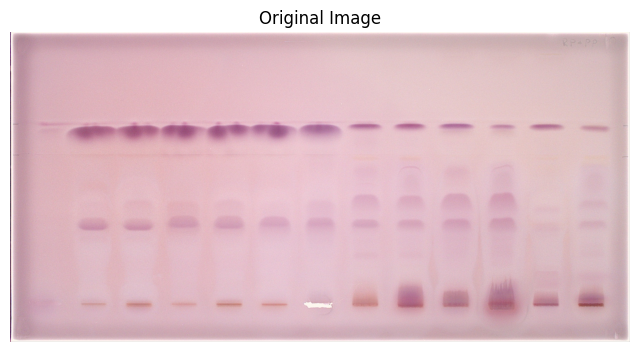

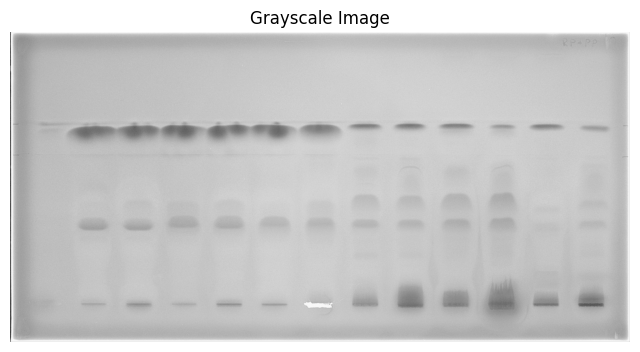

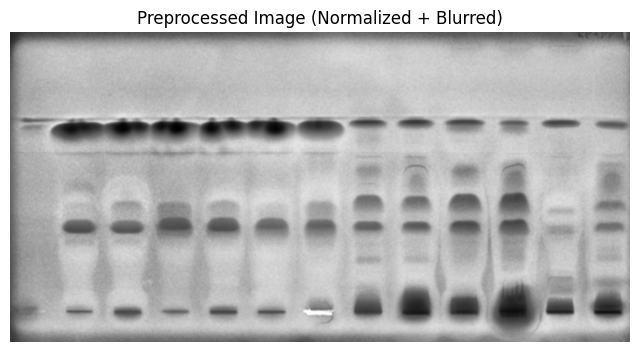

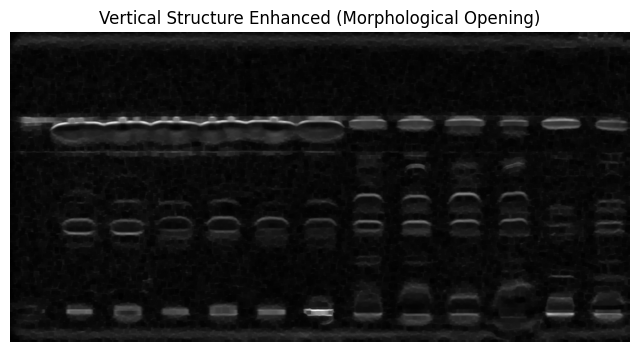

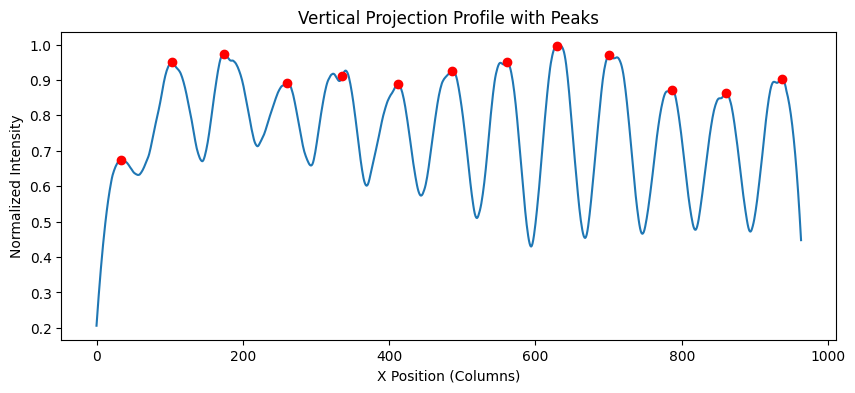

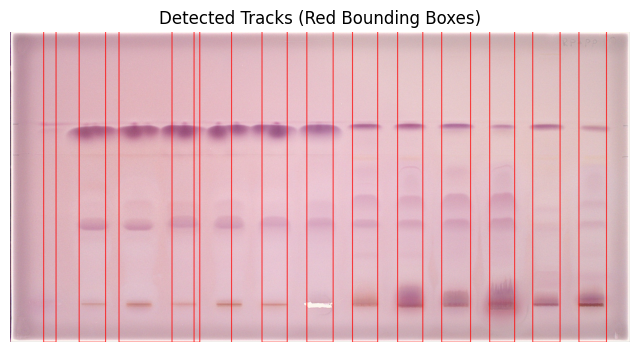

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths, savgol_filter

# ============================
# STEP 1 — STANDARDIZE INPUT
# ============================

def preprocess_image(image_path, target_width=1024, crop_percent=0.03):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize
    h, w = gray.shape
    scale = target_width / w
    new_h = int(h * scale)
    resized = cv2.resize(gray, (target_width, new_h))

    # ============================
    #  Crop borders to remove noise
    # ============================
    h2, w2 = resized.shape

    crop_x = int(w2 * (crop_percent ))
    crop_y = int(h2 * crop_percent)

    cropped = resized[
        crop_y : h2 - crop_y,
        crop_x : w2 - crop_x
    ]

    # ============================
    # CLAHE (contrast enhancement)
    # ============================
    clahe = cv2.createCLAHE(
        clipLimit=5.0,
        tileGridSize=(8, 8)
    )
    equalized = clahe.apply(cropped)

    # Optional smoothing
    blurred = cv2.GaussianBlur(equalized, (5, 5), 0)

    return img, gray, blurred, scale, crop_x


# ====================================
# STEP 2 — ENHANCE VERTICAL STRUCTURES
# ====================================

# def enhance_vertical_structures(image):
#     # Invert image (important for dark tracks)
#     inverted = 255 - image

#     # Vertical kernel
#     kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 50))

#     # Opening on inverted image
#     opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

#     return opened
def enhance_vertical_structures(image):

    # Invert image (helps when tracks are dark)
    inverted = 255 - image

    # Apply Sobel filter
    sobelx = cv2.Sobel(
        inverted,
        cv2.CV_64F,
        0,   # dx
        1,   # dy
        ksize=5
    )

    # Convert to absolute values
    sobelx = np.absolute(sobelx)

    # Normalize to 0–255
    sobelx = cv2.normalize(sobelx, None, 0, 255, cv2.NORM_MINMAX)

    # Convert to uint8
    sobelx = sobelx.astype(np.uint8)

    # -----------------------------
    # 🔹 Convert to binary mask
    # -----------------------------
    _, mask = cv2.threshold(
        sobelx,
        40,          # threshold value (tune this)
        255,
        cv2.THRESH_BINARY
    )

    # -----------------------------
    # 🔹 Morphological Closing
    # -----------------------------
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed = cv2.morphologyEx(sobelx, cv2.MORPH_CLOSE, kernel)

    return closed

# ====================================
# STEP 3 — VERTICAL PROJECTION + PEAKS
# ====================================

def detect_tracks(enhanced_image):

    # Column-wise projection
    projection = np.sum(enhanced_image, axis=0)

    # Normalize
    projection = projection / np.max(projection)

    smoothed_projection = savgol_filter(
        projection,
        window_length=41,
        polyorder=3
    )

    # ----------------------------
    # 🔥 ENSEMBLE PEAK DETECTION
    # ----------------------------
    std_val = np.std(smoothed_projection)

    all_peaks = []

    # Multiple prominence scales
    for scale in [0.1, 0.2, 0.3, 0.4]:

        prominence = scale * std_val
        distance = len(projection) // 20

        peaks, _ = find_peaks(
            smoothed_projection,
            prominence=prominence,
            # distance=distance
        )

        all_peaks.extend(peaks)

    all_peaks = np.array(all_peaks)

    # ----------------------------
    # 🔥 CLUSTER PEAKS (merge nearby)
    # ----------------------------
    if len(all_peaks) == 0:
        return [], smoothed_projection, [], []

    all_peaks = np.sort(all_peaks)

    clusters = []
    current = [all_peaks[0]]

    tolerance = 20  # pixels

    for p in all_peaks[1:]:
        if abs(p - current[-1]) <= tolerance:
            current.append(p)
        else:
            clusters.append(current)
            current = [p]

    clusters.append(current)

    # Final peaks = mean of clusters
    final_peaks = [int(np.mean(c)) for c in clusters]

    # Confidence = how many times detected
    confidence = [len(c) for c in clusters]

    # ----------------------------
    # Band width estimation
    # ----------------------------
    results = peak_widths(
        smoothed_projection,
        final_peaks,
        rel_height=0.5   # more stable than 0.05
    )

    left_ips = results[2]
    right_ips = results[3]

    print("Confidence per peak:", confidence)

    return final_peaks, smoothed_projection, left_ips, right_ips




# ====================================
# STEP 4 — DRAW RED BOXES
# ====================================

# def draw_track_boxes(original_img, peaks, scale, crop_x):
#     img_copy = original_img.copy()

#     peaks_resized = peaks + crop_x
#     peaks_original = np.sort(peaks_resized / scale)

#     for i in range(len(peaks_original) - 1):

#         x1 = int(peaks_original[i])
#         x2 = int(peaks_original[i+1])

#         y1 = 0
#         y2 = img_copy.shape[0]

#         cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,0,255), 2)

#         center_x = int((x1+x2)/2)

#         cv2.putText(
#             img_copy,
#             f"B{i+1}",
#             (center_x-10,40),
#             cv2.FONT_HERSHEY_SIMPLEX,
#             0.8,
#             (0,0,255),
#             2
#         )

#     return img_copy
def draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x):
    img_copy = original_img.copy()

    for left, right in zip(left_ips, right_ips):

        # Convert from cropped coordinates → original coordinates
        x1 = int((left + crop_x) / scale)
        x2 = int((right + crop_x) / scale)

        y1 = 0
        y2 = img_copy.shape[0]

        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0,0,255), 2)

    return img_copy


# ============================
# MAIN PIPELINE
# ============================

image_path = "download/1_1_1_5_2_48_1_1_1_198.tif"  # <-- replace with your image
# image_path = "Sugar.jpg"  # <-- replace with your image

original_img, gray_img, preprocessed, scale, crop_x = preprocess_image(image_path)

enhanced = enhance_vertical_structures(preprocessed)

peaks, projection, left_ips, right_ips = detect_tracks(enhanced)

result = draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x)

print("Number of detected tracks:", len(peaks))

# ----------------------------
# Track spacing in millimeters
# ----------------------------
# Provide the real-world width (in mm) represented by the FULL original image width.
# Example: if the camera sees 60 mm across the full image width, set known_image_width_mm = 60.0
known_image_width_mm = 100.0  # <-- set this (float, in mm)

mm_per_pixel = None if known_image_width_mm is None else float(known_image_width_mm) / float(original_img.shape[1])

# Average distance between tracks (center-to-center)
if len(peaks) > 1 and mm_per_pixel is not None:
    peak_positions_original_px = np.sort(np.array(peaks, dtype=float) / scale)
    track_distances_px = np.diff(peak_positions_original_px)
    avg_distance_mm = float(np.mean(track_distances_px) * mm_per_pixel)
    print(f"Average distance between tracks (mm): {avg_distance_mm:.3f}")
elif len(peaks) <= 1:
    print("Average distance between tracks (mm): N/A (need at least 2 tracks)")
else:
    print("Average distance between tracks (mm): N/A (set known_image_width_mm first)")


# ============================
# VISUALIZATION SECTION
# ============================

plt.figure(figsize=(15, 10))

# 1️⃣ Original Image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()


# 2️⃣ Grayscale
plt.figure(figsize=(8, 6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


# 3️⃣ Preprocessed (Blurred + Normalized)
plt.figure(figsize=(8, 6))
plt.imshow(preprocessed, cmap='gray')
plt.title("Preprocessed Image (Normalized + Blurred)")
plt.axis("off")
plt.show()


# 4️⃣ Enhanced Vertical Structures
plt.figure(figsize=(8, 6))
plt.imshow(enhanced, cmap='gray')
plt.title("Vertical Structure Enhanced (Morphological Opening)")
plt.axis("off")
plt.show()


# 5️⃣ Projection Profile
plt.figure(figsize=(10, 4))
plt.plot(projection)
plt.plot(peaks, projection[peaks], "ro")
plt.title("Vertical Projection Profile with Peaks")
plt.xlabel("X Position (Columns)")
plt.ylabel("Normalized Intensity")
plt.show()


# 6️⃣ Final Result with Red Boxes
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Tracks (Red Bounding Boxes)")
plt.axis("off")
plt.show()